# Session 1 — Model Comparison with MLflow

**Goal:** Train three model types (Logistic Regression, Random Forest, Gradient Boosted Trees)
and use the MLflow UI to compare their performance.

**Business question:** For a churn model, which metric should we optimize?
- **Accuracy**: Overall correct predictions (misleading with class imbalance)
- **Precision**: Of predicted churners, how many actually churned? (false alarm rate)
- **Recall**: Of actual churners, how many did we catch? (missed customers)
- **F1**: Harmonic mean of precision and recall (balanced)

For churn, **recall** is often prioritized — a missed churner costs more than an unnecessary retention offer.

In [0]:
%run ../utils/config

In [0]:
%pip install ../bundle/wheels/ databricks-feature-engineering --quiet

In [0]:
import yaml, mlflow


config_path = "../common/config.yml"
with open(config_path) as f:
    config = yaml.safe_load(f)

# Construct the experiment name
current_user = spark.sql("SELECT current_user()").first()[0]
experiment_name = f"/Users/{current_user}/churn_{safe_username}"
print(f"Experiment: {experiment_name}")

## Set Up the Feature Store

Before training, we publish our features to the **Unity Catalog Feature Engineering** table.

**Why?** Two layers work together to prevent train/serving skew:

1. **Feature Store (this step)** — VALUE consistency.  
   Feature values are stored once in a Delta table and retrieved identically at training and serving time. No risk of a different code path computing `TotalCharges` differently in the scoring pipeline.

2. **`features.py` sklearn pipeline** — TRANSFORMATION consistency.  
   Imputation, scaling, and one-hot encoding are defined once and embedded in the MLflow artifact. The same transformations run everywhere.

The Feature Store table (`churn_features`) will be the source of truth for all future training runs, including the automated retrain job in Session 2.

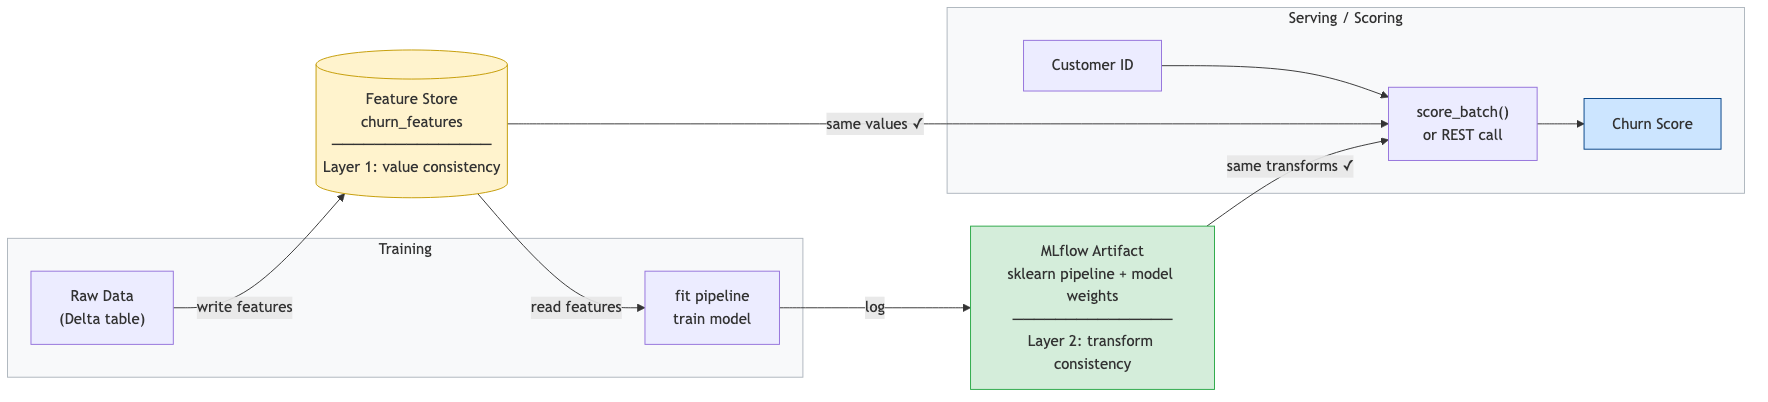

In [0]:
from databricks.feature_engineering import FeatureEngineeringClient, FeatureLookup

fe = FeatureEngineeringClient()
feature_table = f"{catalog}.{schema}.churn_features"

# Feature columns + lookup key
feature_cols = (
    config["feature_columns"]["numeric"]
    + config["feature_columns"]["categorical"]
    + ["customerID"]
)

# Read from the shared source table
raw_df = spark.table(f"{catalog}.`00_shared`.telco_churn")
features_df = raw_df.select(*feature_cols).dropDuplicates(["customerID"])

# Create the table on first run; merge (upsert) on subsequent runs
try:
    fe.create_table(
        name=feature_table,
        primary_keys=["customerID"],
        df=features_df,
        description="Telco churn features — source of truth for training and serving",
    )
    print(f"✓ Created feature table: {feature_table}")
except Exception as e:
    if "already exists" in str(e).lower():
        fe.write_table(name=feature_table, df=features_df, mode="merge")
        print(f"✓ Updated feature table: {feature_table}")
    else:
        raise

print(f"  Rows: {features_df.count():,}")

# Build the training set — Feature Store joins labels with feature lookups by customerID
label_df = raw_df.select("customerID", config.get("target_column", "Churn"))

training_set = fe.create_training_set(
    df=label_df,
    feature_lookups=[
        FeatureLookup(
            table_name=feature_table,
            lookup_key="customerID",
        )
    ],
    label=config.get("target_column", "Churn"),
    exclude_columns=["customerID"],
)
print(f"✓ Training set created — {label_df.count():,} labels linked to feature table")

## Train Three Models

The following cell will create three MLflow runs in your experiment — one per model type defined in `config.yml`: 
- Logistic Regression, 
- Random Forest, 
- Gradient Boost with Trees

Expect this to take 1-2 minutes.

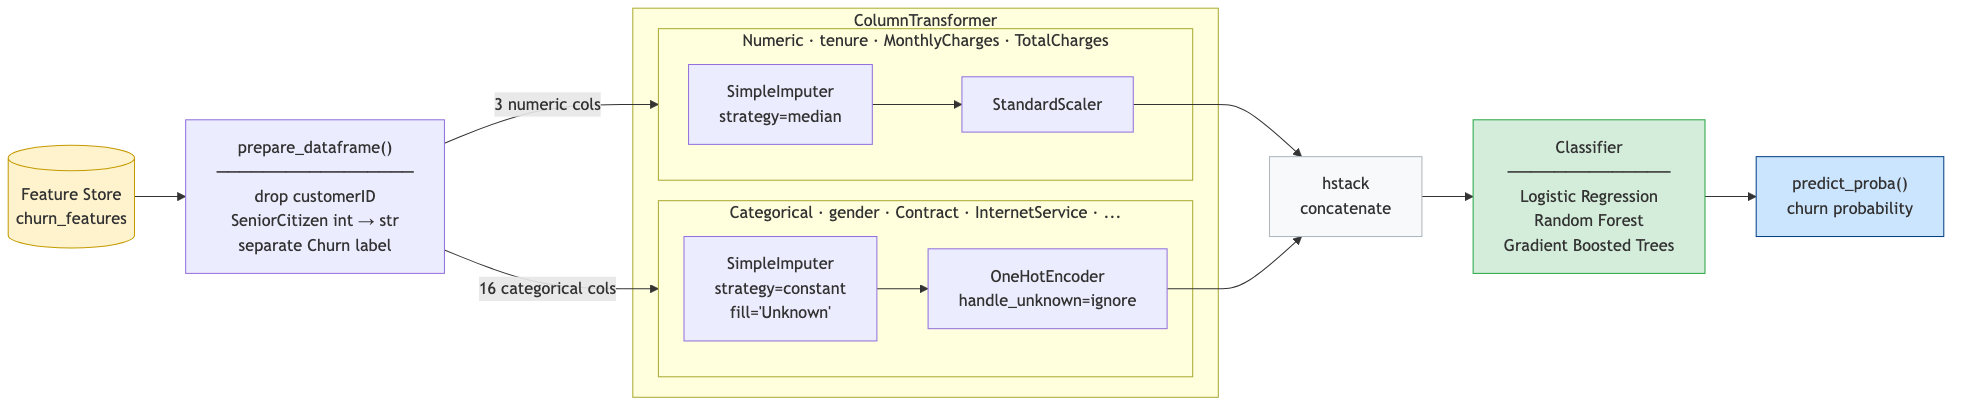

In [0]:
import warnings
from churn_model.train import run_all_models

with warnings.catch_warnings():
    warnings.filterwarnings("ignore", category=UserWarning, module="mlflow")
    results = run_all_models(
        catalog=catalog,
        schema=schema,
        config=config,
        experiment_name=experiment_name,
        fe=fe,
        training_set=training_set,
    )

print("\nAll models trained!")

## View Results in MLflow UI

1. Open **Experiments** from the left sidebar in a new browser tab
2. Find your <span style="color:cc0000;background-color:#e0e0e0;font-family:courier">churn_{safe_username}</span> experiment.
3. Select all three runs → click **Compare**
4. Look at the **Parallel Coordinates** plot

**Questions to discuss:**
- Which model has the highest F1?
- Which has the highest Recall?
- Is there a precision-recall trade-off visible?
- How much does training time differ between models?

In [0]:
# Also view results programmatically
print(f"{'Model':<30} {'F1':>8} {'ROC-AUC':>10} {'Recall':>8} {'Precision':>10}")
print("-" * 68)
for r in results:
    m = r.metrics
    print(f"{r.model_type:<30} {m['test_f1']:>8.4f} {m['test_roc_auc']:>10.4f} "
          f"{m['test_recall']:>8.4f} {m['test_precision']:>10.4f}")

## Find the Best Run

Let's programmatically identify the best model by F1 score.

In [0]:
from churn_model.evaluate import get_best_run

best_run_id, best_model_type, best_metrics = get_best_run(
    experiment_name=experiment_name,
    metric="test_f1",
)

print(f"Best model : {best_model_type}")
print(f"Run ID     : {best_run_id}")
print(f"F1         : {best_metrics['test_f1']:.4f}")
print(f"ROC-AUC    : {best_metrics['test_roc_auc']:.4f}")
print(f"Recall     : {best_metrics['test_recall']:.4f}")

# Save for next notebook
dbutils.jobs.taskValues.set("best_run_id", best_run_id)
dbutils.jobs.taskValues.set("best_model_type", best_model_type)


<div style="
  border-left: 4px solid #f44336;
  background: #ffebee;
  padding: 14px 18px;
  border-radius: 4px;
  margin: 16px 0;
">
  <strong style="display:block; color:#c62828; margin-bottom:6px; font-size: 1.1em;">Copy the Run ID</strong>
  <div style="color:#333;">

**NOTE:**  After the cell finishes running, Copy the **Run ID** from the output above.  You will need this run ID in the next notebook to register the model.
  </div>
</div>

## Discussion

- Logistic Regression typically wins on this dataset by a small margin
- The difference between models is often small — MLOps process matters more than model selection
- MLflow makes it easy to re-run this comparison after retraining on new data

➡️ Next: [05_register_and_serve.ipynb]($./05_register_and_serve) — register the best model and deploy it